# Pipeline Overview

DB health at a glance: posting counts by status, source breakdown, and what's waiting in each stage.

In [1]:
import sys
sys.path.insert(0, '..')
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import select, func, text
from sqlalchemy.orm import Session
from src.db import get_engine, Posting

engine = get_engine(Path('../data/jobs.db'))
pd.set_option('display.max_colwidth', 80)

## Status pipeline

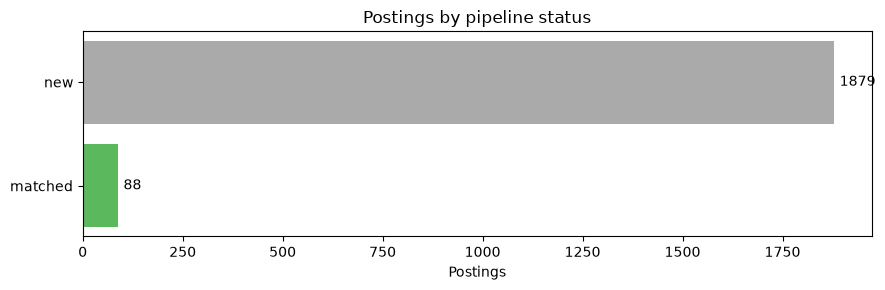

 status  count
    new   1879
matched     88


In [2]:
with Session(engine) as s:
    rows = s.execute(
        select(Posting.status, func.count().label('count'))
        .group_by(Posting.status)
        .order_by(func.count().desc())
    ).all()

STATUS_ORDER = ['new', 'ranked', 'matched', 'generated', 'reviewed', 'applied', 'skipped']
df_status = pd.DataFrame(rows, columns=['status', 'count'])
df_status['status'] = pd.Categorical(df_status['status'], categories=STATUS_ORDER, ordered=True)
df_status = df_status.sort_values('status')

colours = {
    'new': '#aaa', 'ranked': '#4c9be8', 'matched': '#5cb85c',
    'generated': '#f0ad4e', 'reviewed': '#9b59b6',
    'applied': '#2ecc71', 'skipped': '#e74c3c',
}

fig, ax = plt.subplots(figsize=(9, 3))
bars = ax.barh(
    df_status['status'], df_status['count'],
    color=[colours.get(s, '#aaa') for s in df_status['status']]
)
ax.bar_label(bars, padding=4)
ax.set_xlabel('Postings')
ax.set_title('Postings by pipeline status')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(df_status.to_string(index=False))

## Source breakdown

In [3]:
with Session(engine) as s:
    rows = s.execute(
        select(Posting.source, Posting.company, func.count().label('n'))
        .group_by(Posting.source, Posting.company)
        .order_by(func.count().desc())
    ).all()

df_src = pd.DataFrame(rows, columns=['source', 'company', 'postings'])
print(df_src.to_string(index=False))

    source    company  postings
greenhouse Databricks       774
     ashby     Openai       722
greenhouse    Elastic       174
greenhouse     Twilio       149
     ashby     Cohere       138
greenhouse   Deepmind        10


## What's waiting at each stage

In [4]:
for stage in ['new', 'ranked', 'matched', 'generated']:
    with Session(engine) as s:
        n = s.scalar(select(func.count()).where(Posting.status == stage))
    print(f'{stage:12s}: {n} posting(s) ready to advance')

new         : 1879 posting(s) ready to advance
ranked      : 0 posting(s) ready to advance
matched     : 88 posting(s) ready to advance
generated   : 0 posting(s) ready to advance


## Recently added postings

In [5]:
with Session(engine) as s:
    recent = s.scalars(
        select(Posting).order_by(Posting.created_at.desc()).limit(10)
    ).all()

df_recent = pd.DataFrame([
    {'created': p.created_at, 'company': p.company, 'title': p.title, 'status': p.status}
    for p in recent
])
df_recent

,created,company,title,status
0,2026-07-18 14:48:13,Openai,"Technical Program Manager, Compute Infrastructure",new
1,2026-07-18 14:48:13,Openai,Research Engineer,matched
2,2026-07-18 14:48:13,Openai,Account Director - Tokyo,new
3,2026-07-18 14:48:13,Openai,"Software Engineer, RL Training Infra",matched
4,2026-07-18 14:48:13,Openai,"Research Engineer, Retrieval & Search, Applied Engineering",new
5,2026-07-18 14:48:13,Openai,"Researcher, Robustness & Safety Training",matched
6,2026-07-18 14:48:13,Openai,"Software Engineer, Scaled Abuse",new
7,2026-07-18 14:48:13,Openai,"Software Engineer, Data Infrastructure",new
8,2026-07-18 14:48:13,Openai,Training: ML Framework Engineer,new
9,2026-07-18 14:48:13,Openai,"Software Engineer, Developer Productivity",new


## Coverage — companies & locations

Which companies are in the DB, how many postings each contributed, and where they're located. Useful for spotting gaps (companies you expected but aren't here means they're not on Greenhouse/Ashby, or the slug isn't in `config/profile.yaml`).

In [6]:
from sqlalchemy import Integer

with Session(engine) as s:
    rows = s.execute(
        select(
            Posting.company,
            Posting.source,
            func.count().label('total'),
            func.sum(func.cast(Posting.status == 'skipped', Integer)).label('skipped'),
        )
        .group_by(Posting.company, Posting.source)
        .order_by(func.count().desc())
    ).all()

df_companies = pd.DataFrame(rows, columns=['company', 'source', 'total', 'skipped'])
df_companies['kept'] = df_companies['total'] - df_companies['skipped']
df_companies['skip_%'] = (df_companies['skipped'] / df_companies['total'] * 100).round(0).astype(int).astype(str) + '%'
df_companies[['company', 'source', 'total', 'kept', 'skip_%']]

,company,source,total,kept,skip_%
0,Databricks,greenhouse,774,774,0%
1,Openai,ashby,722,722,0%
2,Elastic,greenhouse,174,174,0%
3,Twilio,greenhouse,149,149,0%
4,Cohere,ashby,138,138,0%
5,Deepmind,greenhouse,10,10,0%


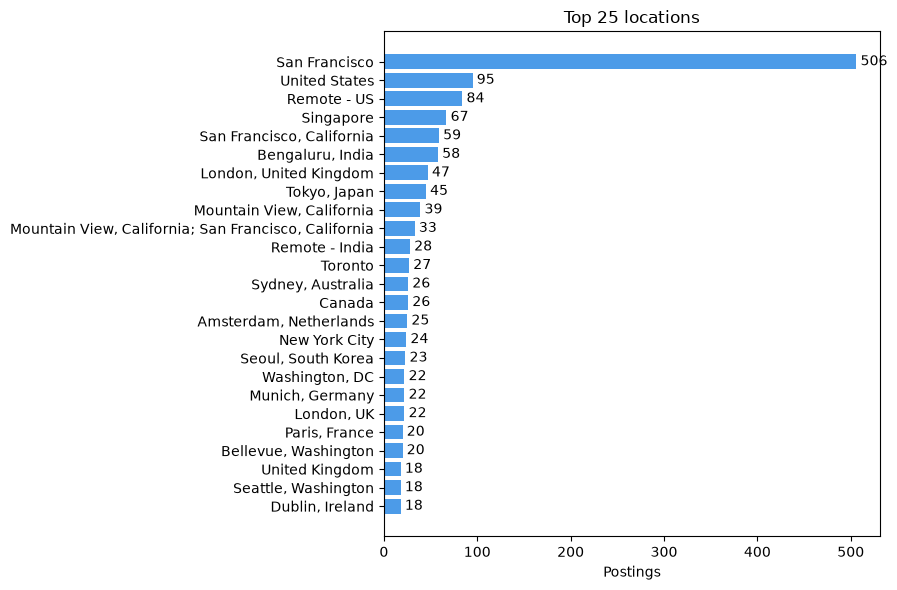

In [7]:
# Top locations across all postings
with Session(engine) as s:
    rows = s.execute(
        select(Posting.location, func.count().label('n'))
        .where(Posting.location != None, Posting.location != '')
        .group_by(Posting.location)
        .order_by(func.count().desc())
        .limit(25)
    ).all()

df_loc = pd.DataFrame(rows, columns=['location', 'count'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(df_loc['location'][::-1], df_loc['count'][::-1], color='#4c9be8')
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel('Postings')
ax.set_title('Top 25 locations')
plt.tight_layout()
plt.show()

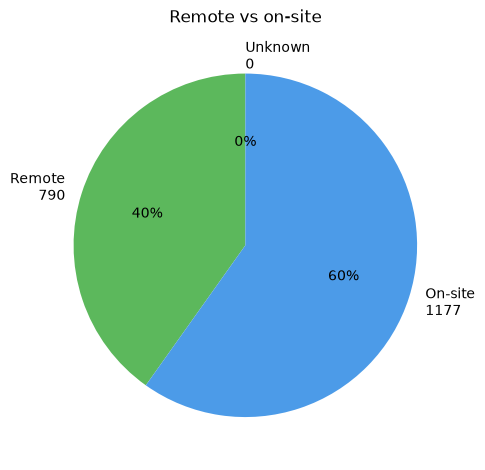

In [8]:
# Remote vs on-site split
with Session(engine) as s:
    remote_n = s.scalar(select(func.count()).where(Posting.remote == True))
    onsite_n = s.scalar(select(func.count()).where(Posting.remote == False))
    null_n   = s.scalar(select(func.count()).where(Posting.remote == None))

labels = ['Remote', 'On-site', 'Unknown']
sizes  = [remote_n, onsite_n, null_n]
colors = ['#5cb85c', '#4c9be8', '#aaa']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie([s for s in sizes], labels=[f'{l}\n{s}' for l, s in zip(labels, sizes)],
       colors=colors, autopct='%1.0f%%', startangle=90)
ax.set_title('Remote vs on-site')
plt.tight_layout()
plt.show()

### Watchlist gap check

Companies in `config/profile.yaml` watchlist that are **not** in the DB — these are the ones the fetcher misses. Check `config/sources.yaml` for why (unsupported ATS, unresolved slug, proprietary portal).

In [9]:
import yaml, re

with open('../config/profile.yaml') as f:
    profile = yaml.safe_load(f)
with open('../config/sources.yaml') as f:
    sources = yaml.safe_load(f)

watchlist = profile.get('watchlist', [])

# slugify for fuzzy matching: lowercase, strip punctuation/parens
def slug(s): return re.sub(r'[^a-z0-9]', '', s.lower())

with Session(engine) as s:
    db_companies = {slug(r[0]) for r in s.execute(select(Posting.company).distinct()).all()}

sourced_slugs = {slug(c) for grp in sources.values() if grp for c in grp}

rows = []
for w in watchlist:
    in_db = slug(w) in db_companies
    in_sources = slug(w) in sourced_slugs
    status = 'in DB' if in_db else ('in sources.yaml' if in_sources else 'MISSING')
    rows.append({'company': w, 'status': status})

df_gaps = pd.DataFrame(rows)
df_gaps.style.apply(
    lambda col: col.map({'in DB': 'background: #d4edda', 'in sources.yaml': 'background: #fff3cd', 'MISSING': 'background: #f8d7da'}),
    subset=['status']
)

,company,status
0,Apple,MISSING
1,Google,MISSING
2,Microsoft,MISSING
3,Meta,MISSING
4,Waze,MISSING
5,Aidoc,MISSING
6,Navina,MISSING
7,Checkout.com,MISSING
8,Samsung (AFSL),MISSING
9,Zendesk,MISSING
